# Solution: Graphical EDA — Swiss EV Charging Stations

**Dataset:** Swiss public EV charging stations (source: [Swiss Federal Office of Energy, OICP open data](https://data.geo.admin.ch/ch.bfe.ladestellen-elektromobilitaet/))

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/ev_charging_stations.csv')
print('Shape:', df.shape)
df.head(3)

Shape: (2442, 15)


,evse_id,station_name,street,city,postal_code,lat,lon,power_kw,power_type,amperage,voltage,plug_type,is_open_24h,renewable_energy,auth_mode
0,CH*CCI*E22078,SIG CERN Esplanade des Particules,SIG CERN Esplanade des Particules,Meyrin,1217,46.23432,6.055602,22.0,AC_3_PHASE,32,230,Type 2 Outlet,True,False,NFC RFID Classic
1,CH*CCI*E22076,SIG CERN Esplanade des Particules,SIG CERN Esplanade des Particules,Meyrin,1217,46.23432,6.055602,22.0,AC_3_PHASE,32,230,Type 2 Outlet,True,False,NFC RFID Classic
2,CH*CCI*E22079,SIG CERN Esplanade des Particules,SIG CERN Esplanade des Particules,Meyrin,1217,46.23432,6.055602,22.0,AC_3_PHASE,32,230,Type 2 Outlet,True,False,NFC RFID Classic


### Task 1 — Histogram of `power_kw`

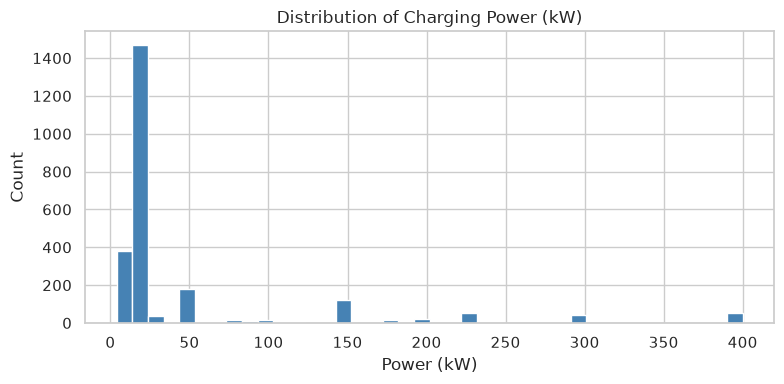

Observation: strongly right-skewed. The vast majority of stations provide 22 kW (AC).
A small number of DC fast-chargers (150-400 kW) create a long tail to the right.


In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['power_kw'], bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Power (kW)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Charging Power (kW)')
plt.tight_layout()
plt.show()

print('Observation: strongly right-skewed. The vast majority of stations provide 22 kW (AC).')
print('A small number of DC fast-chargers (150-400 kW) create a long tail to the right.')

### Task 2 — Box plot: `power_kw` by `power_type`

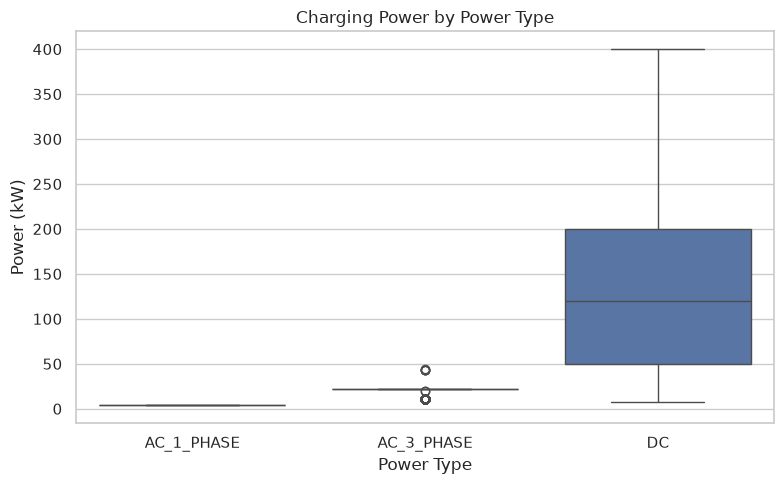

Observation: DC chargers have much higher median power and wider spread.
AC 3-phase stations are tightly clustered around 22 kW.


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='power_type', y='power_kw', ax=ax, order=['AC_1_PHASE', 'AC_3_PHASE', 'DC'])
ax.set_xlabel('Power Type')
ax.set_ylabel('Power (kW)')
ax.set_title('Charging Power by Power Type')
plt.tight_layout()
plt.show()

print('Observation: DC chargers have much higher median power and wider spread.')
print('AC 3-phase stations are tightly clustered around 22 kW.')

### Task 3 — Bar chart: top 10 cities by station count

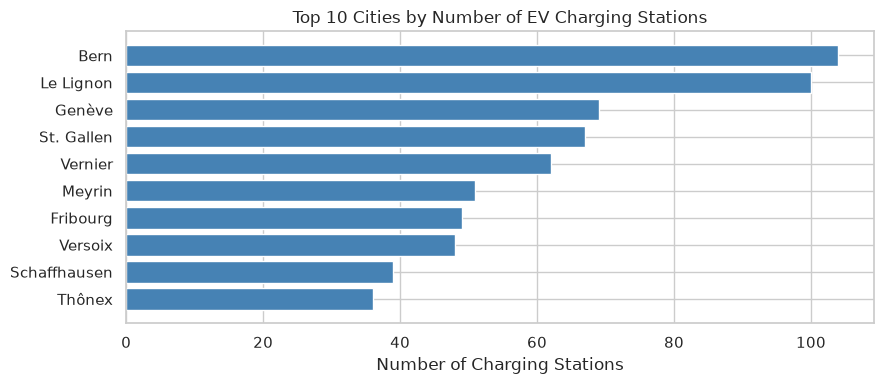

In [4]:
top10 = df['city'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top10.index[::-1], top10.values[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Number of Charging Stations')
ax.set_title('Top 10 Cities by Number of EV Charging Stations')
plt.tight_layout()
plt.show()

### Task 4 — QQ plot of `power_kw`

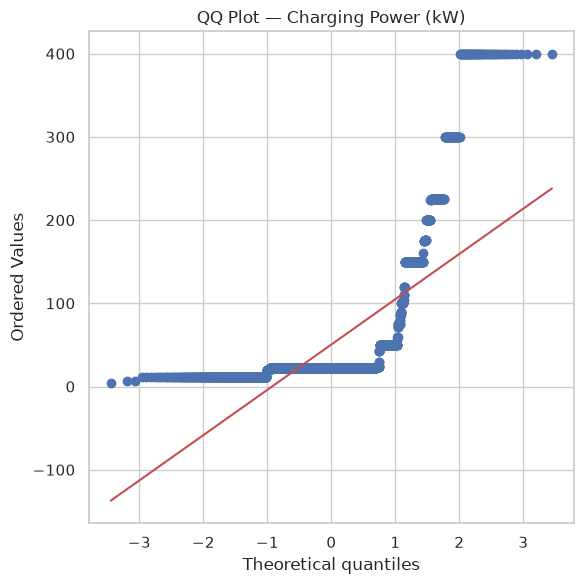

Observation: strong deviation from the diagonal line, especially in the upper tail.
power_kw is clearly NOT normally distributed — it is heavily right-skewed.


In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(df['power_kw'], dist='norm', plot=ax)
ax.set_title('QQ Plot — Charging Power (kW)')
plt.tight_layout()
plt.show()

print('Observation: strong deviation from the diagonal line, especially in the upper tail.')
print('power_kw is clearly NOT normally distributed — it is heavily right-skewed.')

### Task 5 — Scatter plot: `voltage` vs. `amperage` coloured by `power_type`

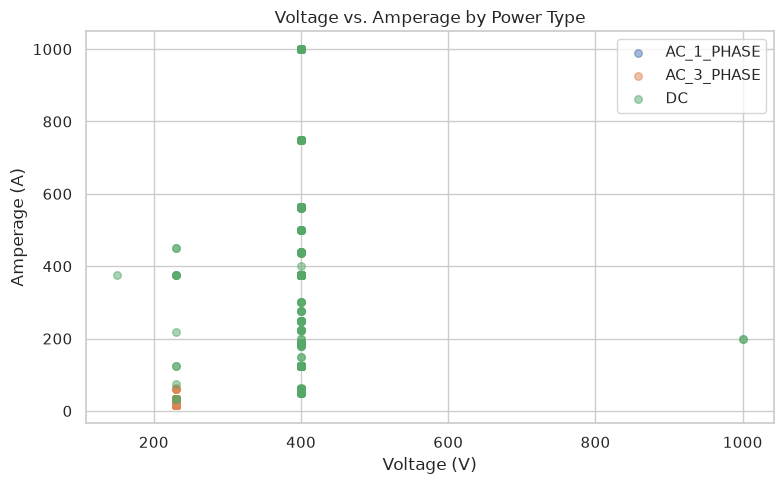

Observation: DC stations form a distinct cluster at higher voltages (400-800 V) with high amperage.
AC stations cluster at 230 V (1-phase) or 400 V (3-phase) with lower amperage.


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for ptype, grp in df.groupby('power_type'):
    ax.scatter(grp['voltage'], grp['amperage'], label=ptype, alpha=0.5, s=30)
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Amperage (A)')
ax.set_title('Voltage vs. Amperage by Power Type')
ax.legend()
plt.tight_layout()
plt.show()

print('Observation: DC stations form a distinct cluster at higher voltages (400-800 V) with high amperage.')
print('AC stations cluster at 230 V (1-phase) or 400 V (3-phase) with lower amperage.')

### Task 6 — Scatter plot matrix

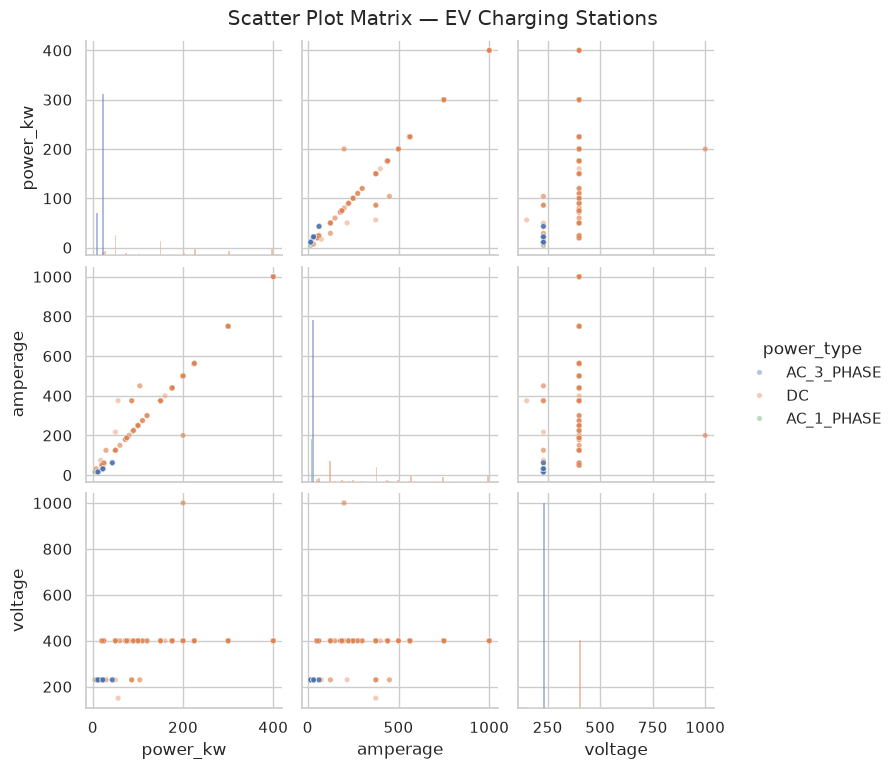

In [7]:
num_cols = ['power_kw', 'amperage', 'voltage']
g = sns.pairplot(
    df[num_cols + ['power_type']],
    hue='power_type',
    diag_kind='hist',
    plot_kws={'alpha': 0.4, 's': 15}
)
g.fig.suptitle('Scatter Plot Matrix — EV Charging Stations', y=1.02)
plt.show()

### Task 7 — Hexbin plot: `voltage` vs. `amperage`

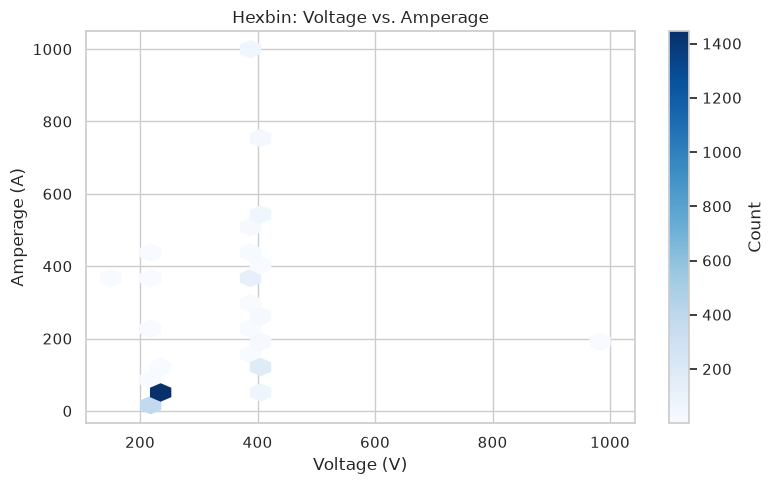

Observation: two dense clusters are visible — one for AC (230/400 V, low amperage)
and one for DC (higher voltage, high amperage).


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(df['voltage'], df['amperage'], gridsize=25, cmap='Blues', mincnt=1)
plt.colorbar(hb, ax=ax, label='Count')
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Amperage (A)')
ax.set_title('Hexbin: Voltage vs. Amperage')
plt.tight_layout()
plt.show()

print('Observation: two dense clusters are visible — one for AC (230/400 V, low amperage)')
print('and one for DC (higher voltage, high amperage).')

### Task 8 — Correlation heatmap

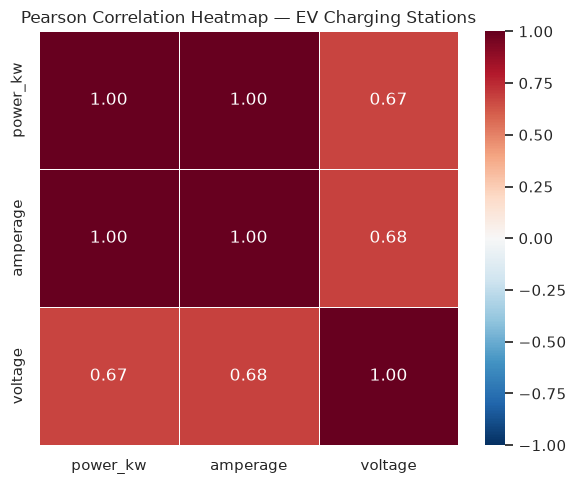

Observation: power_kw and amperage are strongly positively correlated.
Higher charging power requires higher current (P = U x I).


In [9]:
corr = df[num_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Pearson Correlation Heatmap — EV Charging Stations')
plt.tight_layout()
plt.show()

print('Observation: power_kw and amperage are strongly positively correlated.')
print('Higher charging power requires higher current (P = U x I).')

## Jupyter notebook --footer info--
(please always provide this at the end of each notebook)

In [10]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('------------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('------------------------------------')

------------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-10-01 07:37:47
Python Version: 3.13.5
------------------------------------
